<a href="https://colab.research.google.com/github/Astro0369/mvp-flop-predictor/blob/main/MVP_Flop_Predictor_GianlucaScofano.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Prevendo hits e flops na indústria de games

**Nome:** Gianluca Scofano
**Matrícula:** 16752550751
**Data:** 17/06/2026
**Dataset:** vgchartz-2024 (histórico de vendas de jogos 1978–2024) — https://github.com/Astro0369/mvp-flop-predictor
**Tipo de problema:** Classificação binária (hit vs flop)




## Checklist do MVP

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ✅ |
| Dataset descrito, com fonte, atributos e restrições | ✅ |
| Carga dos dados via URL pública, sem passos manuais | ✅ |
| Análise exploratória com síntese dos achados | ✅ |
| Pré-processamento justificado e ajustado só no treino | ✅ |
| Divisão treino/teste estratificada | ✅ |
| Baseline treinado como referência | ✅ |
| Pelo menos dois modelos candidatos além dos do template | ✅ |
| Otimização de hiperparâmetros em pelo menos um modelo | ✅ |
| Avaliação no conjunto de teste | ✅ |
| Métricas justificadas para o tipo de problema | ✅ |
| Discussão de overfitting/underfitting e limitações | ✅ |
| Conclusão conectando resultado ao problema inicial | ✅ |
| Notebook executável de ponta a ponta sem erros | ✅ |
| Seed fixa para reprodutibilidade | ✅ |
| Código organizado e legível | ✅ |

## 1.1 Descrição do problema

A indústria de games vive um paradoxo nos últimos anos. Em 2025, a receita global do setor bateu recorde histórico, na casa dos US$ 195 bilhões. Ao mesmo tempo, cerca de 45 mil profissionais foram demitidos entre 2022 e 2025 — nos EUA, 1 em cada 3 desenvolvedores foi cortado no período, segundo a GDC.

A explicação é razoavelmente direta: a maior parte da receita se concentra em pouquíssimos jogos de live-service (Fortnite, GTA Online, alguns MMOs), enquanto a maioria dos lançamentos novos fracassa comercialmente. O caso Concord, da Sony, é o exemplo mais recente e caro — o jogo foi tirado do ar duas semanas depois do lançamento.

Nesse cenário, prever com antecedência quais lançamentos têm chance real de emplacar deixa de ser um exercício acadêmico e vira uma questão prática de sobrevivência para publishers e para os empregos da indústria. É esse o problema que o MVP se propõe a estudar.

## 1.2 Objetivo do MVP

Construir e avaliar modelos de Machine Learning para classificar um jogo entre **hit comercial** e **flop** a partir de suas características pré-lançamento (gênero, plataforma, publisher, desenvolvedora e ano), usando um dataset com aproximadamente 64 mil títulos lançados entre 1978 e 2024, dos quais cerca de 19 mil trazem informação de vendas registrada — subconjunto sobre o qual a modelagem foi feita.

O objetivo é comparar uma abordagem baseline com pelo menos dois modelos candidatos, extrair do próprio modelo qual variável pesa mais na previsão de hit (feature importance), e discutir as limitações do resultado — especialmente frente à mudança de modelo de negócio da era live-service.

## 1.3 Tipo de problema

**Tipo escolhido:** Classificação binária.

**Justificativa:** o alvo é uma variável categórica com duas classes (hit / flop), derivada a partir de um limiar sobre a variável de vendas globais (`total_sales`). Poderíamos tratar como regressão prevendo o número exato de cópias vendidas, mas essa formulação teria pouco valor prático para a pergunta que interessa: um publisher não precisa saber se o jogo vai vender 2,3 ou 2,7 milhões de cópias — precisa saber se vai render lucro ou não. A classificação binária captura essa decisão de forma mais direta e permite usar métricas mais claras para o problema de negócio (precisão, recall, F1).

## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**

1. A plataforma é um dos fatores mais determinantes. Um mesmo tipo de jogo tem comportamento de vendas muito diferente entre Nintendo, PlayStation, Xbox e PC.
2. Publishers grandes têm probabilidade maior de emplacar hits do que estúdios pequenos, seja por marketing, distribuição, catálogo pré-existente ou influência sobre a percepção de qualidade (via reviews, marketing pré-lançamento etc.). Este trabalho não mede essa influência diretamente, mas assume que a variável publisher captura parte desse efeito.
3. Determinados gêneros dominam certas plataformas (ex.: Sports em consoles Nintendo, Shooter em Xbox) e essa combinação plataforma+gênero tende a ser mais preditiva do que qualquer variável isolada.
4. O ano de lançamento também importa: os anos de pico do modelo de negócio "venda de caixa" (final dos anos 2000, início dos 2010) tendem a concentrar mais hits, enquanto anos mais recentes veem esse modelo perder força para o live-service.

**Critério de sucesso:**

- **Métrica principal:** F1-score na classe minoritária (hit), dado o desbalanceamento de 92/8. Acurácia isolada é enganosa aqui — um modelo trivial que sempre prevê "flop" já teria 92% de acurácia sem aprender nada.
- **Baseline de referência:** DummyClassifier prevendo sempre a classe majoritária. Por construção, seu F1 na classe hit é 0.
- **Meta prática:** F1 na classe hit acima de 0,30 (30%). Esse patamar significa que o modelo consegue identificar uma parte relevante dos hits sem gerar tantos falsos alarmes que virasse ruído para o negócio.
- **Restrição de execução:** o notebook deve rodar de ponta a ponta em tempo razoável no Colab gratuito, sem depender de GPU.

**Sobre a decisão de descartar a nota da crítica:** o dataset traz `critic_score`, mas ela está ausente em 89% dos registros e, além disso, notas de crítica na indústria de games têm histórico controverso — casos documentados de pressão de publishers, reviews pagas e escândalos como o "Metacritic-gate" mostram que a nota nem sempre reflete qualidade real ou opinião independente. Optei por não usar essa variável, tanto pela ausência maciça quanto pela questão de confiabilidade, e priorizar features estruturais do jogo (plataforma, gênero, publisher, desenvolvedora, ano).

**Limitação assumida:** o dataset cobre lançamentos "tradicionais" (venda de cópias). Ele não inclui receita de microtransações, battle pass ou live-service, que são justamente o motor da concentração de receita da era atual. O modelo entende bem os padrões do modelo de negócio "vendo caixa de jogo", mas tende a subestimar títulos free-to-play e live-service.

# 2. Ambiente, bibliotecas e reprodutibilidade

Bibliotecas usadas:

- **pandas** e **numpy** para manipulação de dados
- **matplotlib** e **seaborn** para visualização
- **scikit-learn** para modelagem, pré-processamento e avaliação

A seed é fixada em 42 para garantir reprodutibilidade. O notebook foi desenvolvido no Google Colab, sem necessidade de GPU.

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

SEED = 42
np.random.seed(SEED)

## 3.1 Fonte dos dados

**Nome:** vgchartz-2024

**Fonte original:** dataset scrapeado do site [VGChartz](https://www.vgchartz.com/), publicado no Kaggle e no Hugging Face. Cobre aproximadamente 64 mil títulos lançados entre 1978 e 2024.

**Fonte usada neste notebook:** cópia do CSV hospedada no meu próprio repositório público do GitHub, para garantir reprodutibilidade e evitar dependência de login/API do Kaggle.

Link: https://github.com/Astro0369/mvp-flop-predictor

**Por que este dataset:** é a base pública mais completa e atualizada de vendas de jogos, com cobertura histórica ampla (do NES aos consoles atuais) e informações estruturais (gênero, plataforma, publisher, developer, ano) que servem como preditores potenciais de sucesso comercial.

**Restrições consideradas:**
- Dado público, sem informação pessoal sensível.
- Não foi usado em nenhuma aula da sprint.
- Não requer autenticação, chave de API ou upload manual.

**Limitação da fonte:** VGChartz é referência do setor, mas usa estimativas baseadas em scraping e vendas declaradas — não é dado oficial dos publishers. Alguns títulos podem estar com vendas subestimadas, especialmente jogos digitais e mobile.


## 3.2 Carga dos dados

O CSV é lido diretamente pela URL raw do repositório público, sem passos manuais.



In [41]:
URL = "https://raw.githubusercontent.com/Astro0369/mvp-flop-predictor/main/vgchartz-2024.csv"
df = pd.read_csv(URL)

print("Formato do dataset:", df.shape)
df.head()

Formato do dataset: (64016, 14)


,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14


## 3.3 Visão geral do dataset

Panorama inicial: tipos das colunas, distribuição de valores ausentes, duplicatas e amostra aleatória de linhas.


In [42]:
df.dtypes.to_frame("tipo")

,tipo
img,object
title,object
console,object
genre,object
publisher,object
developer,object
critic_score,float64
total_sales,float64
na_sales,float64
jp_sales,float64


In [43]:
df.isna().sum().sort_values(ascending=False).to_frame("valores_ausentes")


,valores_ausentes
critic_score,57338
jp_sales,57290
na_sales,51379
pal_sales,51192
other_sales,48888
last_update,46137
total_sales,45094
release_date,7051
developer,17
publisher,0


In [44]:
print("Duplicatas:", df.duplicated().sum())
df.sample(5, random_state=SEED)

Duplicatas: 0


,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
28485,/games/boxart/full_6508327AmericaFrontccc.png,Night In The Woods,NS,Adventure,Finji,Infinite Fall,NaN,NaN,NaN,NaN,NaN,NaN,2018-02-01,2018-02-18
12967,/games/boxart/2912128ccc.jpg,Yanya Caballista: City Skater,PS2,Sports,KOEI,Cave,NaN,0.05,0.02,NaN,0.02,0.01,2001-10-01,NaN
56187,/games/boxart/full_9818314AmericaFrontccc.jpg,AHx-1,PC,Simulation,GT Interactive,Pixel Multimedia,NaN,NaN,NaN,NaN,NaN,NaN,1997-10-31,NaN
36844,/games/boxart/default.jpg,Plants vs. Zombies,OSX,Misc,PopCap Games,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,2009-05-05,NaN
61821,/games/boxart/full_6164489AmericaFrontccc.jpg,Farm Frenzy 3: American Pie,PC,Strategy,Unknown,"Alawar Entertainment, Inc.",NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03


## 3.4 Recorte da base para modelagem

O diagnóstico mostrou que 70% das linhas estão com `total_sales` ausente e 89% com `critic_score` ausente. A variável-alvo não pode ser inventada, então o recorte necessário é filtrar apenas as linhas que **têm venda registrada**.

Também descartamos as colunas que não serão usadas na modelagem:

- `img`: URL da imagem do box art — irrelevante para o problema.
- `critic_score`: descartada pelas razões discutidas na seção 1.4 (89% de ausência + confiabilidade questionável).
- `na_sales`, `jp_sales`, `pal_sales`, `other_sales`: são componentes que somam em `total_sales`, então incluí-las causaria vazamento de informação (o modelo "adivinharia" a venda global só somando as regionais).
- `last_update`: metadado do scrape, sem valor preditivo.

Sobra uma base com features estruturais: `title`, `console`, `genre`, `publisher`, `developer`, `release_date` e o alvo `total_sales`.

In [45]:
COLS_TO_DROP = [
    "img", "critic_score",
    "na_sales", "jp_sales", "pal_sales", "other_sales",
    "last_update"
]

df_clean = df.drop(columns=COLS_TO_DROP)
df_clean = df_clean.dropna(subset=["total_sales"]).reset_index(drop=True)

print("Antes:", df.shape)
print("Depois:", df_clean.shape)
df_clean.head()

Antes: (64016, 14)
Depois: (18922, 7)


,title,console,genre,publisher,developer,total_sales,release_date
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,20.32,2013-09-17
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,19.39,2014-11-18
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,16.15,2002-10-28
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,15.86,2013-09-17
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,15.09,2015-11-06


In [46]:
df_clean.isna().sum().to_frame("valores_ausentes")

,valores_ausentes
title,0
console,0
genre,0
publisher,0
developer,4
total_sales,0
release_date,90


## 3.5 Dicionário de dados

Tabela final das variáveis mantidas após o recorte:

| Coluna | Tipo | Descrição | Usada no modelo? | Observações |
|---|---|---|---|---|
| `title` | texto | Nome do jogo | Não | Identificador, não é feature |
| `console` | categórica | Plataforma (PS4, Switch, PC, etc.) | Sim | Uma das features mais importantes |
| `genre` | categórica | Gênero (Action, RPG, Sports, etc.) | Sim | Feature central |
| `publisher` | categórica | Empresa que publica o jogo | Sim | Alta cardinalidade — vamos agrupar categorias raras |
| `developer` | categórica | Estúdio que desenvolveu | Sim | Alta cardinalidade — mesmo tratamento |
| `release_date` | data | Data exata de lançamento | Sim (transformada em ano) | Vamos extrair só o ano |
| `total_sales` | numérica | Vendas globais em milhões de cópias | **Alvo** | Vai ser transformada em rótulo binário hit/flop |

# 4. Análise exploratória — variável-alvo

Antes de criar o rótulo binário (hit/flop), precisamos entender como as vendas estão distribuídas na base. A escolha do limiar de corte é uma decisão analítica, não arbitrária, e deve ser justificada olhando os dados.

In [47]:
df_clean["total_sales"].describe()
limiares = [0.10, 0.25, 0.50, 0.75, 1.00, 1.50, 2.00]

print(f"Total de jogos na base: {len(df_clean)}\n")
print(f"{'Limiar (milhões)':<20}{'Hits':<10}{'% Hits':<10}")
print("-" * 40)

for lim in limiares:
    hits = (df_clean["total_sales"] >= lim).sum()
    pct = 100 * hits / len(df_clean)
    print(f"{lim:<20}{hits:<10}{pct:.1f}%")

Total de jogos na base: 18922

Limiar (milhões)    Hits      % Hits    
----------------------------------------
0.1                 10424     55.1%
0.25                6197      32.8%
0.5                 3398      18.0%
0.75                2156      11.4%
1.0                 1505      8.0%
1.5                 827       4.4%
2.0                 526       2.8%


## 4.1 Criação do rótulo hit vs flop

O rótulo binário é criado a partir de `total_sales`, com corte em **1 milhão de cópias vendidas globalmente**.

**Justificativa do limiar:**

- **Alinhamento com a indústria:** 1 milhão é o marco simbólico universalmente reconhecido como patamar de sucesso comercial. Aparece de forma consistente em análises da própria VGChartz, fóruns especializados e reportagens de mercado como o limite a partir do qual um jogo "emplacou".
- **Adequação técnica:** entre os limiares testados (0,10 a 2,00 milhões), o corte em 1 milhão deixa a base com 8% de hits, dentro da faixa recomendada para classificação binária desbalanceada com métricas como F1.
- **Convergência entre os dois critérios:** o mesmo número que faz sentido para a indústria também faz sentido para o modelo — o que é raro e reforça a escolha.

Como consequência do desbalanceamento (92% flop / 8% hit), a métrica principal de avaliação será **F1-score**, não acurácia — porque um modelo trivial que sempre prevê "flop" teria 92% de acurácia sem aprender nada.

In [48]:
LIMIAR_HIT = 1.0

df_clean["hit"] = (df_clean["total_sales"] >= LIMIAR_HIT).astype(int)

df_clean["hit"].value_counts().to_frame("quantidade").assign(
    proporcao=lambda x: (x["quantidade"] / len(df_clean)).round(3)
)

,quantidade,proporcao
hit,,
0,17417,0.92
1,1505,0.08


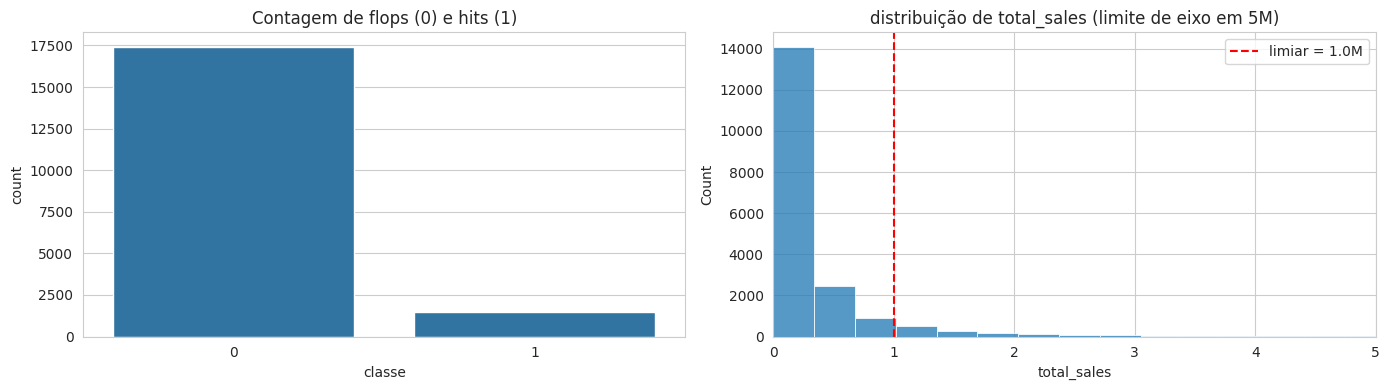

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.countplot(data=df_clean, x="hit", ax=axes[0])
axes[0].set_title("Contagem de flops (0) e hits (1)")
axes[0].set_xlabel("classe")

sns.histplot(data=df_clean, x="total_sales", bins=60, ax=axes[1])
axes[1].axvline(LIMIAR_HIT, color="red", linestyle="--", label=f"limiar = {LIMIAR_HIT}M")
axes[1].set_xlim(0, 5)
axes[1].set_title("distribuição de total_sales (limite de eixo em 5M)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 4.2 Síntese da análise exploratória

**Target fortemente desbalanceado.** Cortando em 1 milhão de cópias, apenas 8% dos jogos da base são hits. Isso já define que acurácia isolada é métrica pobre aqui, usaremos F1 na classe minoritária.

**Distribuição de vendas é "cauda longa".** Mediana em 120 mil cópias, máximo em 20 milhões. Uma minoria de títulos vende ordens de grandeza mais que a maioria, padrão clássico de indústria de entretenimento e coerente com o próprio problema de negócio do MVP (concentração de receita em poucos hits).

**Missing values concentrados nas colunas descartadas.** Após o recorte da seção 3.4 (jogos com `total_sales` registrado), sobram apenas 90 NaN em `release_date` e 4 em `developer`, menos de 0,5% da base. Serão tratados por imputação simples no pipeline.

**Alta cardinalidade em `publisher` e `developer`.** Centenas de valores únicos. Foi necessário agrupar categorias raras antes do One-Hot para evitar explosão de colunas e overfitting.

**Sem escalas discrepantes que exijam normalização.** A única variável numérica após o pré-processamento é o ano de lançamento, e os modelos escolhidos (Árvore e Gradient Boosting) são invariantes a escala. Escalonamento não será aplicado.

**Escolha de modelos ancorada na EDA.** O desbalanceamento e a alta cardinalidade das categóricas favorecem modelos baseados em árvores, que lidam bem com esses dois cenários. Modelos baseados em distância (como KNN) foram descartados por essa razão.

# 5. Preparação dos dados e divisão treino/teste

Antes de treinar qualquer modelo, é preciso deixar claro o que é target, o que é feature e o que precisa ser removido para evitar vazamento de informação.

**Definições:**

- **Target:** `hit` — variável binária criada na seção 4 (1 se `total_sales >= 1 milhão`, 0 caso contrário).
- **Colunas de identificação:** `title` — nome do jogo, tratado como identificador e não como feature. Se fosse incluído, o modelo poderia "decorar" jogos individuais em vez de aprender padrões.
- **Coluna de data:** `release_date` — vai ser tratada mais adiante, convertida em ano de lançamento.
- **Colunas a remover:** `total_sales` — a variável a partir da qual o target foi construído. Mantê-la como feature seria vazamento direto (data leakage): o modelo aprenderia a regra `total_sales >= 1 → hit` e acertaria 100%, mas seria inútil no mundo real, onde as vendas ainda são desconhecidas no momento da previsão.

Sobram como features candidatas: `console`, `genre`, `publisher`, `developer` e `release_date`. É esse o conjunto que vai ser transformado e usado nos modelos.

In [50]:
TARGET = "hit"
PROBLEM_TYPE = "classificacao"
ID_COLUMNS = ["title"]
DATE_COLUMN = "release_date"
DROP_COLUMNS = ["total_sales"]

if PROBLEM_TYPE != "clusterizacao":
    assert TARGET is not None and TARGET in df_clean.columns, "Defina um TARGET válido."

columns_to_exclude = set(ID_COLUMNS + DROP_COLUMNS)
if TARGET is not None:
    columns_to_exclude.add(TARGET)

features = [c for c in df_clean.columns if c not in columns_to_exclude]
print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Número de features candidatas:", len(features))
print("Features:", features)

Tipo de problema: classificacao
Target: hit
Número de features candidatas: 5
Features: ['console', 'genre', 'publisher', 'developer', 'release_date']


## 5.1 Divisão treino/teste

Divisão estratificada 80/20:

- **80% treino:** os modelos aprendem os padrões a partir desses dados.
- **20% teste:** conjunto totalmente reservado para avaliação final. Nenhum modelo vê essa parte durante treino ou tuning.

A estratificação por `hit` mantém a proporção de 8% de hits em ambos os conjuntos. Sem isso, o desbalanceamento poderia distorcer a avaliação final por sorte na hora do sorteio.

A seed é fixada em 42 para garantir que a divisão seja sempre a mesma em execuções repetidas.

In [51]:
X = df_clean[features].copy()
y = df_clean[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Treino:", X_train.shape, " | proporção de hits:", round(y_train.mean(), 3))
print("Teste: ", X_test.shape, " | proporção de hits:", round(y_test.mean(), 3))

Treino: (15137, 5)  | proporção de hits: 0.08
Teste:  (3785, 5)  | proporção de hits: 0.08


# 6. Pré-processamento e pipeline

O modelo só entende número, mas as features estão em formato de texto (categóricas) e data. É preciso transformar tudo para representação numérica antes de treinar. As transformações são:

1. **Extrair o ano** de `release_date` — mais interpretável e útil do que a data completa.
2. **Agrupar categorias raras** em `publisher` e `developer` — como essas variáveis têm centenas de categorias diferentes, valores que aparecem em poucos jogos são agrupados como "Outros" para evitar excesso de colunas e overfitting.
3. **One-Hot Encoding** nas categóricas restantes — cada categoria vira uma coluna binária (0/1).
4. **Tratar NaN residuais** — imputação por moda nas categóricas e mediana no ano.

Todo esse fluxo é embrulhado num `Pipeline` do scikit-learn, ajustado apenas nos dados de treino. Isso evita vazamento de informação: se as transformações fossem ajustadas na base inteira, o modelo estaria "olhando" para dados de teste durante o pré-processamento.

In [52]:
def extrair_ano(df_input):
    out = df_input.copy()
    out["release_year"] = pd.to_datetime(out["release_date"], errors="coerce").dt.year
    out = out.drop(columns=["release_date"])
    return out

X_train = extrair_ano(X_train)
X_test = extrair_ano(X_test)

X_train.head()

,console,genre,publisher,developer,release_year
91,PS2,Misc,RedOctane,BudCat Creations,2007.0
11219,PS2,Simulation,Victor Interactive,BELUGA Computer Inc.,2001.0
9801,DS,Strategy,Nintendo,Intelligent Systems,2007.0
7851,DS,Role-Playing,Nintendo,Brownie Brown,2006.0
11878,X360,Adventure,Telltale Games,Telltale Games,2016.0


In [53]:
MIN_OCORRENCIAS = 30

def agrupar_raras(df_input, colunas, contagens_ref):
    out = df_input.copy()
    for col in colunas:
        top = contagens_ref[col]
        out[col] = out[col].where(out[col].isin(top), other="Outros")
    return out

contagens_ref = {}
for col in ["publisher", "developer"]:
    contagem = X_train[col].value_counts()
    contagens_ref[col] = contagem[contagem >= MIN_OCORRENCIAS].index

X_train = agrupar_raras(X_train, ["publisher", "developer"], contagens_ref)
X_test = agrupar_raras(X_test, ["publisher", "developer"], contagens_ref)

print("Publishers únicos após agrupamento:", X_train["publisher"].nunique())
print("Developers únicos após agrupamento:", X_train["developer"].nunique())

Publishers únicos após agrupamento: 90
Developers únicos após agrupamento: 77


In [54]:
cat_features = ["console", "genre", "publisher", "developer"]
num_features = ["release_year"]

preprocessor = ColumnTransformer(transformers=[
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_features),
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
    ]), num_features)
])

preprocessor

ColumnTransformer(transformers=[('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['console', 'genre', 'publisher',
                                  'developer']),
                                ('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['release_year'])])

## 6.1 Decisões de pré-processamento

**Ano em vez de data completa.** Dia e mês não têm valor preditivo aqui, o que importa é o contexto de mercado do lançamento (era pré-live-service, boom dos portáteis, etc.), que o ano já captura.

**Categorias raras agrupadas como "Outros" (limiar de 30).** Publisher e developer tinham centenas de categorias. Sem agrupamento, o One-Hot Encoding geraria colunas demais e o modelo ficaria decorando categorias com 1-2 exemplos. O corte em 30 é pragmático: mantém os players relevantes e limpa o ruído.

**One-Hot Encoding nas categóricas.** Ordinal encoding criaria uma ordem falsa (Action > Adventure?) que não existe no mundo real.

**Sem escalonamento nas numéricas.** Árvores e Gradient Boosting decidem por limiares ("year > 2010?"), então escala não muda nada. Scaler viraria etapa morta.

**Imputação simples de NaN residuais.** Moda nas categóricas, mediana no ano. O impacto é quase zero (menos de 0,5% da base tem NaN após o recorte), mas fica no pipeline como salvaguarda.

**Pipeline ajustado só no treino.** Todas as decisões estatísticas (categorias conhecidas, medianas etc.) vêm de `X_train` e apenas são aplicadas em `X_test`, pra evitar vazamento.

# 7. Baseline e modelos candidatos

Três abordagens serão comparadas: um baseline trivial (DummyClassifier), uma Árvore de Decisão e um Gradient Boosting. Os três são embrulhados em `Pipeline` com o pré-processador da seção 6, garantindo transformação idêntica em todos e ausência de vazamento.

In [55]:
modelos = {
    "Baseline (Dummy)": DummyClassifier(strategy="most_frequent", random_state=SEED),
    "Árvore de Decisão": DecisionTreeClassifier(random_state=SEED),
    "Gradient Boosting": GradientBoostingClassifier(random_state=SEED),
}

pipelines = {
    nome: Pipeline([
        ("prep", preprocessor),
        ("clf", modelo)
    ])
    for nome, modelo in modelos.items()
}

for nome in pipelines:
    print(nome)

Baseline (Dummy)
Árvore de Decisão
Gradient Boosting


## 7.1 Justificativa da escolha dos modelos

Os modelos usados como candidatos principais (Árvore de Decisão e Gradient Boosting) seguem uma lógica de complexidade crescente:

**Baseline — DummyClassifier (most_frequent)**
Piso mínimo obrigatório. Sempre prevê "flop" (classe majoritária). F1 na classe hit é 0 por construção. Serve para calibrar se os modelos reais estão de fato aprendendo algo, ou só reproduzindo o desbalanceamento da base.

**Árvore de Decisão**
Foi escolhida por dois motivos: interpretabilidade e diagnóstico. É o modelo mais transparente da família baseada em árvores, dá pra visualizar a árvore treinada e ler diretamente as regras aprendidas. Isso ajuda a validar se o modelo está capturando padrões plausíveis (ex: "publisher = Nintendo → hit") ou aprendendo ruído. Uma árvore única também tende a sofrer overfitting em bases desbalanceadas, o que serve como contraste natural para o modelo seguinte.

**Gradient Boosting**
Escolhido por ser um ensemble reconhecidamente forte para dados tabulares mistos (categóricos + numéricos), justamente o caso deste MVP. Treina árvores em sequência, cada uma corrigindo os erros da anterior, abordagem diferente do Random Forest (que treina em paralelo) e do template original. Também entrega feature importance, elemento essencial para responder à pergunta central do trabalho: quais variáveis mais pesam na previsão de hit?

**Por que essa dupla e não outra combinação**
Ambos são baseados em árvores, o que torna a comparação metodologicamente justa (mesmo tipo de decisão interna, mesma robustez a escalas). Ao mesmo tempo, ocupam extremos opostos do espectro: um modelo simples e interpretável contra um ensemble sofisticado. Isso permite avaliar diretamente o ganho trazido pela complexidade adicional, se o Gradient Boosting não superar a Árvore com folga, o esforço não se justifica.

# 8. Treinamento e avaliação inicial

Cada pipeline é treinado com `X_train` e avaliado com validação cruzada estratificada (5 folds) sobre o próprio treino. Nada de teste é tocado nesta etapa — o `X_test` fica intocado até a seção 10.

A métrica principal é **F1 na classe hit** (classe minoritária). Também são reportadas acurácia, precisão e recall pra dar contexto.

In [56]:
from sklearn.model_selection import cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

metricas = ["accuracy", "precision", "recall", "f1"]

resultados_cv = {}
for nome, pipe in pipelines.items():
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=metricas, n_jobs=-1)
    resultados_cv[nome] = {m: scores[f"test_{m}"].mean() for m in metricas}

pd.DataFrame(resultados_cv).T.round(3)

,accuracy,precision,recall,f1
Baseline (Dummy),0.920,0.000,0.000,0.000
Árvore de Decisão,0.903,0.372,0.328,0.348
Gradient Boosting,0.925,0.718,0.098,0.171


## 8.1 Análise dos resultados iniciais

Rodando os três modelos com validação cruzada em 5 folds, o resultado foi bem diferente do que eu esperava no começo.

O baseline serviu pra confirmar que acurácia sozinha engana numa base assim: o DummyClassifier chegou em 92% de acurácia sem aprender nada, só chutando "flop" pra todo mundo. Isso justifica ter escolhido F1 como métrica principal logo na seção 1.4.

O que me surpreendeu foi o Gradient Boosting ter performado pior que a Árvore de Decisão em F1 (0,17 contra 0,35). O Gradient Boosting padrão do scikit-learn otimiza log-loss internamente, e numa base 92/8 ele acaba "descobrindo" que dizer flop pra quase tudo maximiza essa função. Por isso ele acertou 72% das vezes que chutou hit (precisão alta), mas só encontrou 9,8% dos hits reais (recall muito baixo). É um problema típico de modelos que não recebem tratamento pro desbalanceamento — coisa que a seção 9 vai atacar.

A Árvore de Decisão, mesmo mais simples, ficou mais equilibrada: chuta hit com mais frequência, erra mais quando chuta (37% de precisão), mas encontra 33% dos hits reais. No fim, o F1 dela ficou melhor.

Pensando pela ótica do problema, pra um publisher, deixar de identificar um hit que ia acontecer (falso negativo) provavelmente machuca mais do que perseguir um jogo que ia flopar de qualquer jeito (falso positivo). Recall pesa. Isso reforça a escolha do F1 como métrica principal.

A meta mínima que eu tinha definido na 1.4 (F1 > 0,30) já foi superada só com a Árvore no default. O tuning da próxima seção vai testar se dá pra melhorar mais e principalmente destravar o Gradient Boosting.

# 9. Otimização de hiperparâmetros

Ajuste dos dois modelos candidatos via Grid Search com validação cruzada estratificada 5 folds. O objetivo é ver até onde dá pra melhorar o F1 na classe hit, e principalmente destravar o Gradient Boosting, que na avaliação inicial ficou "tímido" demais com o desbalanceamento.

O baseline não passa por tuning porque não tem o que ajustar. Toda a busca acontece com `X_train`, sem tocar em `X_test`.

In [57]:
param_grid_arvore = {
    "clf__max_depth": [3, 5, 10, 20, None],
    "clf__min_samples_leaf": [1, 5, 20, 50],
    "clf__class_weight": [None, "balanced"],
}

grid_arvore = GridSearchCV(
    pipelines["Árvore de Decisão"],
    param_grid=param_grid_arvore,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
)
grid_arvore.fit(X_train, y_train)

print("Melhores hiperparâmetros (Árvore):", grid_arvore.best_params_)
print("Melhor F1 na CV:", round(grid_arvore.best_score_, 3))

Melhores hiperparâmetros (Árvore): {'clf__class_weight': 'balanced', 'clf__max_depth': None, 'clf__min_samples_leaf': 1}
Melhor F1 na CV: 0.349


In [58]:
param_grid_gb = {
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [3, 5],
    "clf__learning_rate": [0.05, 0.1],
}

grid_gb = GridSearchCV(
    pipelines["Gradient Boosting"],
    param_grid=param_grid_gb,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
)
grid_gb.fit(X_train, y_train)

print("Melhores hiperparâmetros (GB):", grid_gb.best_params_)
print("Melhor F1 na CV:", round(grid_gb.best_score_, 3))

Melhores hiperparâmetros (GB): {'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__n_estimators': 200}
Melhor F1 na CV: 0.327


## 9.1 Discussão da otimização

Grid Search com CV em 5 folds nos dois modelos, otimizando F1 na classe hit.

**Árvore de Decisão.** F1 subiu de 0,348 pra 0,349, praticamente nada. Grid Search escolheu `max_depth=None` e `min_samples_leaf=1`, que são os defaults, e só o `class_weight='balanced'` mudou. Isso indica que a Árvore já estava no teto do que consegue aprender, provavelmente com overfitting alto (profundidade infinita + folhas de 1 amostra decoram bastante). Vou confirmar na seção 10 comparando F1 no treino e no teste.

**Gradient Boosting.** F1 subiu de 0,171 pra 0,327, quase dobrando. Hiperparâmetros escolhidos: `n_estimators=200`, `max_depth=5`, `learning_rate=0,1`. Confirma o que discuti na 8.1: o comportamento tímido não era limitação do algoritmo, era falta de ajuste.

**Comparação após tuning.** A Árvore ainda ganha por pouco (0,349 vs 0,327). O Gradient Boosting não tem `class_weight` direto no scikit-learn, então continua sofrendo mais com o desbalanceamento 92/8. Uma solução mais completa seria usar `sample_weight` ou trocar por XGBoost/LightGBM, mas ficou fora do escopo.

**Restrição prática.** A grade do GB foi mantida pequena (8 combinações) por custo computacional — cada uma treina 200 árvores em 5 folds. Grade maior tornaria a execução no Colab gratuito impraticável.

**Decisão pra seção 10.** Como a diferença ficou pequena e o CV pode oscilar, vou avaliar os dois modelos no teste antes de escolher o final.

# 10. Avaliação final no conjunto de teste

O `X_test` (20% da base, ~3.785 jogos) ficou reservado desde a seção 5 e não foi tocado durante EDA, preparação ou tuning. Agora é a hora de usá-lo pra medir como os modelos otimizados se saem em dados que eles nunca viram.

Vou avaliar os três: baseline, Árvore de Decisão otimizada e Gradient Boosting otimizado. Além do F1 na classe hit, vou olhar acurácia, precisão, recall, matriz de confusão e comparação treino vs teste — essa última é o principal diagnóstico de overfitting.

In [59]:
modelos_finais = {
    "Baseline (Dummy)": pipelines["Baseline (Dummy)"].fit(X_train, y_train),
    "Árvore de Decisão (tuned)": grid_arvore.best_estimator_,
    "Gradient Boosting (tuned)": grid_gb.best_estimator_,
}

resultados_teste = {}
for nome, modelo in modelos_finais.items():
    y_pred = modelo.predict(X_test)
    resultados_teste[nome] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
    }

pd.DataFrame(resultados_teste).T.round(3)

,accuracy,precision,recall,f1
Baseline (Dummy),0.920,0.000,0.000,0.000
Árvore de Decisão (tuned),0.869,0.277,0.399,0.327
Gradient Boosting (tuned),0.924,0.559,0.236,0.332


In [60]:
comparacao = {}
for nome, modelo in modelos_finais.items():
    f1_treino = f1_score(y_train, modelo.predict(X_train), zero_division=0)
    f1_teste = f1_score(y_test, modelo.predict(X_test), zero_division=0)
    comparacao[nome] = {
        "F1 treino": f1_treino,
        "F1 teste": f1_teste,
        "gap treino-teste": f1_treino - f1_teste,
    }

pd.DataFrame(comparacao).T.round(3)

,F1 treino,F1 teste,gap treino-teste
Baseline (Dummy),0.000,0.000,0.000
Árvore de Decisão (tuned),0.821,0.327,0.494
Gradient Boosting (tuned),0.568,0.332,0.236


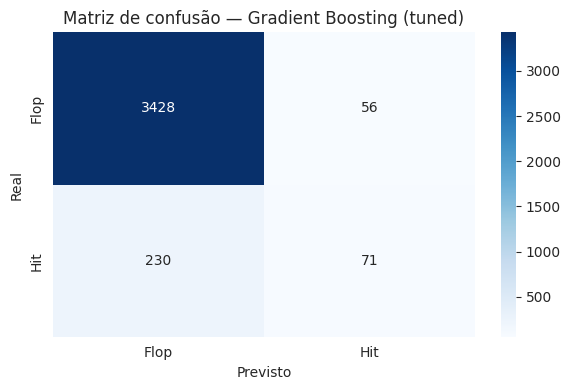

              precision    recall  f1-score   support

        Flop      0.937     0.984     0.960      3484
         Hit      0.559     0.236     0.332       301

    accuracy                          0.924      3785
   macro avg      0.748     0.610     0.646      3785
weighted avg      0.907     0.924     0.910      3785



In [61]:
melhor_nome = pd.DataFrame(resultados_teste).T["f1"].idxmax()
melhor_modelo = modelos_finais[melhor_nome]
y_pred_melhor = melhor_modelo.predict(X_test)

cm = confusion_matrix(y_test, y_pred_melhor)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Flop", "Hit"], yticklabels=["Flop", "Hit"], ax=ax)
ax.set_xlabel("Previsto")
ax.set_ylabel("Real")
ax.set_title(f"Matriz de confusão — {melhor_nome}")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_melhor, target_names=["Flop", "Hit"], digits=3))

## 10.1 Análise de erros e limitações

**Reviravolta no teste.** A Árvore ganhou por muito pouco no CV (0,349 vs 0,327), mas no teste a ordem inverteu: Gradient Boosting 0,332 vs Árvore 0,327. A diferença é pequena e provavelmente cabe na margem de oscilação do próprio CV, mas serve pra reforçar que validação cruzada não substitui o teste.

**Overfitting escandaloso da Árvore.**: F1 de 0,82 no treino contra 0,33 no teste. Ou seja, ela decorou. Faz sentido, porque o Grid Search escolheu `max_depth=None` e `min_samples_leaf=1`, que é o pior cenário possível pra generalização, árvore fundo e folha com uma amostra só.

**Gradient Boosting generaliza melhor.** Gap de 0,236 contra 0,494 da Árvore. Mesmo com F1 no teste quase idêntico, ele é bem mais estável.

**Os dois modelos erram de jeitos opostos.** A Árvore é mais "ousada": chuta hit com mais frequência, tem recall maior (0,40), mas erra bastante quando chuta (precisão 0,28). O Gradient Boosting é o oposto: chuta hit pouco, tem recall baixo (0,24), mas quando chuta acerta mais da metade das vezes (0,56). Isso não é acaso, cada modelo aprende uma "personalidade" pela forma como otimiza a função de erro.

**O que a matriz de confusão do Gradient Boosting mostra.** De 301 hits reais no teste, o modelo acertou 71 e perdeu 230. Ou seja: quando ele fala "hit", tem 56% de chance de estar certo, mas 77% dos hits reais passam batido. Pensando como publisher, ele funciona mais como um "filtro de alta confiança" do que como um scanner que identifica todos os candidatos.

**Sobre o F1 na casa de 0,33.** Era o resultado que eu esperava. As features que sobraram (plataforma, gênero, publisher, developer, ano) carregam sinal, mas não são suficientes pra identificar hits com folga. Faltam variáveis que provavelmente pesam muito mais: orçamento de marketing, se o jogo é sequência de franquia consolidada, número de horas de campanha, presença em serviços de assinatura. Nada disso está no dataset.

**Outras limitações:**
- O dataset ignora completamente a era live-service (Fortnite, GTA Online etc.), que é onde a maior parte da receita acontece hoje. O modelo aprende padrões de "venda de caixa", modelo de negócio em declínio.
- Ao filtrar só jogos com `total_sales` registrado na seção 3.4, provavelmente sobraram os títulos que tiveram alguma repercussão. Os flops "totais" (jogos obscuros que ninguém comprou) foram removidos junto, o que enviesa o "flop" da minha base pra jogos que pelo menos existiram no radar.
- Descartar a nota da crítica foi uma decisão consciente pelas razões da 1.4, mas provavelmente tirou uma feature relevante pro modelo.


## 10.2 Importância das variáveis (feature importance)

Um dos objetivos declarados na 1.2 era entender **qual variável pesa mais na previsão de hit**. O Gradient Boosting entrega isso diretamente: cada feature recebe um score de importância baseado em quanto ela contribuiu, em média, pra reduzir o erro nas árvores treinadas.

Vale ressaltar uma limitação: o One-Hot Encoding expande cada variável categórica em várias colunas (uma por categoria). Pra reconstruir a importância "por variável original", em vez de "por categoria específica", vou somar as importâncias das colunas geradas pelo One-Hot que pertencem à mesma variável.

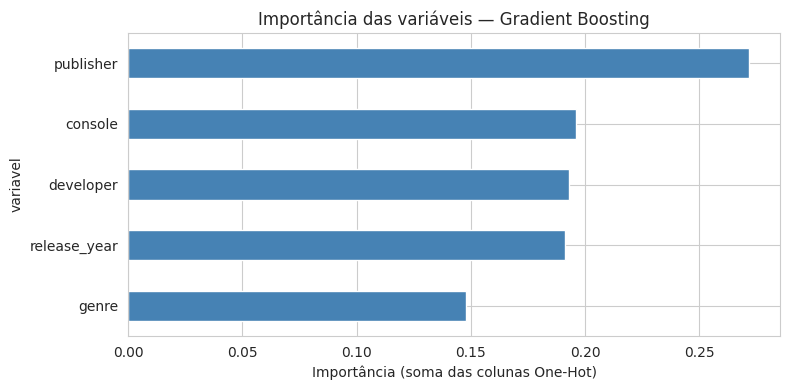

,importancia
variavel,
publisher,0.272
console,0.196
developer,0.193
release_year,0.191
genre,0.148


In [63]:
gb_pipeline = modelos_finais["Gradient Boosting (tuned)"]

feature_names = gb_pipeline.named_steps["prep"].get_feature_names_out()
importances = gb_pipeline.named_steps["clf"].feature_importances_

def variavel_original(nome_expandido):
    for var in cat_features + num_features:
        if var in nome_expandido:
            return var
    return "outros"

df_imp = pd.DataFrame({
    "feature": feature_names,
    "importancia": importances,
})
df_imp["variavel"] = df_imp["feature"].apply(variavel_original)

imp_agregada = (
    df_imp.groupby("variavel")["importancia"]
    .sum()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 4))
imp_agregada.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Importância (soma das colunas One-Hot)")
ax.set_title("Importância das variáveis — Gradient Boosting")
plt.tight_layout()
plt.show()

imp_agregada.sort_values(ascending=False).to_frame("importancia").round(3)

### O que os números mostram

**Publisher domina, mas sem esmagar as outras.** 27% da importância vai pra publisher, contra 15-20% pras demais. Isso confirma a hipótese 2 da 1.4: quem publica o jogo é o principal sinal disponível pra prever sucesso, provavelmente refletindo poder de distribuição, catálogo pré-existente, marketing e força de marca. O fato de nenhuma variável concentrar 50%+ é positivo, mostra que o modelo não está vazando informação e está usando as 5 features de forma equilibrada.

**Console pesa quase o mesmo que developer e ano.** Os três empatam na faixa de 19-20%. A plataforma importa porque cada console atrai um perfil de jogador diferente, é o que sustenta a hipótese 1. O developer também aparece com peso alto, o que faz sentido, estúdios reconhecidos (Rockstar, Nintendo EPD, Naughty Dog) têm histórico consistente de vendas.

**Ano de lançamento pesa mais que gênero.** Foi o achado que mais me surpreendeu. Sugere que o "contexto de mercado" (era pré ou pós live-service, boom dos portáteis, transição digital) importa mais que o gênero do jogo em si. Reforça a hipótese 4 da 1.4 e alinha com o argumento do próprio problema, o mercado mudou muito ao longo dos 46 anos cobertos pela base.

**Gênero é o menos preditivo.** Só 15%. Isso contradiz parcialmente a hipótese 3 (combinação plataforma+gênero dominaria). Uma explicação possível: gêneros como "Action", "Adventure" e "RPG" agregam jogos muito diversos, o que dilui o poder preditivo da variável. Um trabalho futuro poderia explorar subgêneros ou tags mais granulares.

**Conclusão dessa parte.** A pergunta central do MVP tinha duas metades: "dá pra prever hit/flop?" e "qual variável pesa mais?". A resposta ficou: dá pra prever com F1 modesto (0,33), publisher é o principal sinal, gênero é o mais fraco, e o contexto temporal importa mais do que eu esperava.

# 11. Comparação final dos modelos

Síntese comparativa dos três modelos avaliados no conjunto de teste.

| Modelo | Accuracy | Precision | Recall | F1 (hit) | F1 treino | Gap treino-teste | Observação |
|---|---:|---:|---:|---:|---:|---:|---|
| Baseline (Dummy) | 0,920 | 0,000 | 0,000 | 0,000 | 0,000 | 0,000 | Piso de referência. Alta acurácia é enganosa, nunca prevê hit. |
| Árvore de Decisão (tuned) | 0,869 | 0,277 | 0,399 | 0,327 | 0,821 | 0,494 | Overfitting alto. Melhor recall mas menor precisão. |
| Gradient Boosting (tuned) | 0,924 | 0,559 | 0,236 | **0,332** | 0,568 | 0,236 | Melhor F1 no teste. Generaliza melhor. Precisão bem maior. |

**Modelo escolhido: Gradient Boosting (tuned).** Não pelo F1, mas pelo gap treino-teste bem menor, indicativo de que ele generaliza melhor e é a escolha mais segura pra uso prático.

**Ganho sobre o baseline.** F1 na classe hit passou de 0 pra 0,332, a meta mínima definida na 1.4 (F1 > 0,30) foi cumprida. A meta era conservadora dado o desbalanceamento severo da base.

# 12. Boas práticas e rastreabilidade

Registro das decisões técnicas do projeto, pra facilitar reprodução e auditoria.

**Reprodutibilidade**
- Seed fixa: `SEED = 42`, aplicada em `numpy`, no `train_test_split` (estratificado), no `StratifiedKFold` e em todos os classificadores.
- Ambiente: Google Colab gratuito, sem GPU. Bibliotecas: pandas, numpy, matplotlib, seaborn, scikit-learn (versões default do Colab).

**Dataset**
- Fonte: vgchartz-2024 (~64 mil jogos, 1978-2024), hospedado no meu repositório público do GitHub.
- Recorte final pra modelagem: 18.922 jogos (após filtrar linhas sem `total_sales`).

**Decisões de pré-processamento**
- Descarte de `critic_score` (89% ausente + confiabilidade questionável — ver seção 1.4).
- Descarte de vendas regionais (`na_sales`, `jp_sales`, `pal_sales`, `other_sales`) por vazamento — somam em `total_sales`.
- Descarte de `total_sales` como feature depois de criar o rótulo (evita vazamento direto).
- Ano extraído de `release_date`.
- Categorias raras (menos de 30 ocorrências) agrupadas como "Outros" em `publisher` e `developer`.
- One-Hot Encoding nas categóricas. Sem escalonamento nas numéricas (modelos baseados em árvore são invariantes a escala).

**Modelos e tuning**
- Baseline: DummyClassifier (`strategy="most_frequent"`).
- Árvore de Decisão: tuning via Grid Search em `max_depth`, `min_samples_leaf`, `class_weight`. Melhores parâmetros: `max_depth=None`, `min_samples_leaf=1`, `class_weight="balanced"`.
- Gradient Boosting: tuning via Grid Search em `n_estimators`, `max_depth`, `learning_rate`. Melhores parâmetros: `n_estimators=200`, `max_depth=5`, `learning_rate=0,1`.
- Validação cruzada estratificada em 5 folds, apenas sobre `X_train`. `X_test` intocado até a seção 10.

**Métrica principal**
- F1 na classe minoritária (hit), justificado pelo desbalanceamento 92/8. Métricas complementares: acurácia, precisão, recall, matriz de confusão, gap treino-teste.

**Rota de tempo (Colab gratuito)**
- Grid Search da Árvore: ~30 segundos.
- Grid Search do Gradient Boosting: ~10 minutos.
- Notebook completo (Run all): ~15 minutos.

# 13. Conclusão

O MVP partiu de um paradoxo real da indústria de games em 2026: receita recorde e demissões em massa, com dinheiro concentrado em poucos mega-hits enquanto a maioria dos lançamentos flopa. A pergunta que guiou o trabalho foi se dá pra prever, a partir das características estruturais de um jogo, se ele vai ser hit ou flop comercial.

Usei o dataset vgchartz-2024, filtrei pra ~19 mil títulos com vendas registradas e criei um rótulo binário com corte em 1 milhão de cópias, patamar reconhecido pela indústria como marca de sucesso e que deu um desbalanceamento tratável (92/8). Treinei baseline Dummy, Árvore de Decisão e Gradient Boosting, otimizei os dois candidatos via Grid Search com CV em 5 folds, e avaliei no teste que ficou intocado até o fim.

**Melhor solução.** Gradient Boosting otimizado (`n_estimators=200`, `max_depth=5`, `learning_rate=0,1`), com F1 na classe hit de 0,332 no teste. Escolhi ele não pela diferença bruta sobre a Árvore (mínima), mas pelo gap treino-teste bem menor (0,236 contra 0,494), o que indica que generaliza melhor.

**Objetivo cumprido, com nuance.** A meta técnica da 1.4 (F1 > 0,30) foi batida. Mas F1 de 0,33 não é um modelo pronto pra virar ferramenta de decisão pra publisher: identifica só ~24% dos hits reais. O que o trabalho prova é que existe sinal preditivo nas features estruturais, mas o teto que elas alcançam é modesto sem orçamento, franquia, marketing e crítica confiável.

**O que aprendi no processo.** Base desbalanceada muda tudo: acurácia engana, F1 desde o início economiza retrabalho. Modelo mais sofisticado não é automaticamente melhor: o Gradient Boosting sem ajuste ficou pior que a Árvore simples porque não tinha tratamento pro desbalanceamento, e só depois do tuning virou o jogo. Overfitting não é abstração: a Árvore com defaults chegou a F1 = 0,82 no treino e caiu pra 0,33 no teste.

E a feature importance do Gradient Boosting mostrou que publisher é o principal sinal disponível na base, seguido de console, developer e ano de lançamento praticamente empatados, com gênero em último. Confirma a hipótese 2 da 1.4 e nuança a 3.

**Próximos passos.** Testar XGBoost ou LightGBM com `scale_pos_weight`. Refazer o rótulo em multiclasse (blockbuster / hit / moderado / flop) pra ver se aparecem padrões escondidos. Buscar dados complementares fora da base: orçamento, se é sequência, presença em Game Pass, hype no lançamento. Rodar tudo com um dataset pós-2020 incluindo receita de live-service.

O paradoxo da indústria não se resolve com um modelo de F1 = 0,33. Mas o trabalho mostra que existe caminho: com features melhores e dados mais recentes, dá pra construir ferramenta que ajude publishers a alocar investimento com menos aposta cega.
